In [7]:
import netCDF4
import numpy as np
import matplotlib.pyplot as plt
import os
import pandas as pd
import time
from scipy.interpolate import LinearNDInterpolator, NearestNDInterpolator
from scipy.spatial import Delaunay
from joblib import Parallel, delayed
from matplotlib.colors import ListedColormap
from scipy.io import loadmat

from skimage.segmentation import find_boundaries

In [8]:
colormap_data = loadmat('cold2hot.mat')
cold2hot = ListedColormap(colormap_data['colormap'])
hot2cold = ListedColormap(colormap_data['colormap'][::-1])

In [9]:
# 400W045mps
power_level = '400'
scanspeed = '045'
path = os.path.abspath(f'../../0_Moose_Files/{power_level}W{scanspeed}mps/exodus/')
model_path = path+'/HEA_Full.e'
model = netCDF4.Dataset(model_path)

In [10]:
df = pd.read_csv(path+'/HEA_Full.csv')
df.head()

,time,area_h1,area_h2,dt,temp_avg,temp_max,temp_min
0,0.0000,5117.260377,254882.739623,0.0000,0.000000,0.000000,0.000000
1,0.1250,5054.341429,254945.658571,0.1250,300.633340,432.114172,299.999972
2,0.2500,4995.770593,255004.229407,0.1250,301.265888,563.245880,299.999976
3,0.4375,4723.005268,255276.994732,0.1875,302.210791,757.780327,299.999958
4,0.6250,4552.525217,255447.474783,0.1875,303.152794,950.196326,299.999941


In [ ]:
# model.variables.keys()

In [4]:
time_real = np.array(model.variables['time_whole'][:]).reshape((-1, ))
len(time_real)

862

In [5]:
names = model.variables["name_nod_var"]
names.set_auto_mask(False)
var_names = [b"".join(c).decode("latin1") for c in names[:]]
print("Node variables:", var_names)

Node variables: ['bnds', 'cA', 'cA1', 'cA2', 'cB', 'cB1', 'cB2', 'cC', 'cC1', 'cC2', 'cD', 'eta1', 'eta2', 'p', 'temp', 'vel_x', 'vel_y', 'wA', 'wB', 'wC']


In [ ]:
def make_array_parallel(nodes, X_all, Y_all, param, blockname="solid", n_jobs=4, ny=260, nx=1000,):
    start_time = time.time()
    
    # Convert to regular arrays in case they're masked
    x = np.asarray(X_all[nodes])
    y = np.asarray(Y_all[nodes])
    vals = np.asarray(param[:, nodes])  # shape (nt, nnodes_block)

    # Define structured target grid
    xi = np.linspace(x.min(), x.max(), nx)
    yi = np.linspace(y.min(), y.max(), ny)
    Xi, Yi = np.meshgrid(xi, yi)

    nt = vals.shape[0]

    # Precompute Delaunay triangulation for linear interpolation
    tri = Delaunay(np.column_stack((x, y)))

    # Precompute nearest neighbor interpolator (used for NaNs)
    nearest_interp = NearestNDInterpolator(np.column_stack((x, y)), np.zeros_like(x))  # placeholder

    # Function to interpolate a single timestep
    def interp_timestep(t):
        field = vals[t, :]
        linear_interp = LinearNDInterpolator(tri, field)
        Zi = linear_interp(Xi, Yi)
        mask = np.isnan(Zi)
        if np.any(mask):
            Zi[mask] = NearestNDInterpolator(np.column_stack((x, y)), field)(Xi[mask], Yi[mask])
        return Zi

    # Parallel computation over time steps
    arr_list = Parallel(n_jobs=n_jobs)(delayed(interp_timestep)(t) for t in range(nt))
    arr = np.stack(arr_list, axis=2)

    # Flip once after the loop
    arr = np.flip(arr, axis=0)

    end_time = time.time()
    total_time = end_time - start_time

    # print(f"{blockname}: interpolated to shape {arr.shape}")
    print(f"Total time for {blockname}: {total_time:.2f} seconds")

    # return arr, Xi, Yi
    return arr

In [ ]:
parameters = ['vals_nod_var2', 'vals_nod_var5', 'vals_nod_var8', 'vals_nod_var11', 'vals_nod_var12', 'vals_nod_var13', 'vals_nod_var15', 'vals_nod_var16', 'vals_nod_var17',]

nt, nnodes = model.variables[parameters[0]][:].shape
X_all = model.variables['coordx'][:]
Y_all = model.variables['coordy'][:]
# --- Connectivity: get block-specific nodes ---
connect1 = model.variables["connect1"][:] - 1   # film block
connect2 = model.variables["connect2"][:] - 1   # powder block
nodes_block1 = np.unique(connect1.ravel()).astype(int)
nodes_block2 = np.unique(connect2.ravel()).astype(int)

time_index = np.abs(time_real-110).argmin() ## checking only after 110 micro-sec
print(time_index)

In [ ]:
# for i in range(len(parameters)):
for i in [7,8]:
    param = model.variables[parameters[i]][:]
    if i == 0:
        liquid = make_array_parallel(nodes_block2, X_all, Y_all, param, blockname="liquid", n_jobs=6, ny=60)
        solid = make_array_parallel(nodes_block1, X_all, Y_all, param, blockname="solid", n_jobs=6, ny=200)
        # cA = np.flip(np.concatenate((liquid, solid), axis=0), axis=0)
        cA = np.round(np.transpose(np.concatenate((liquid, solid), axis=0), axes=(2, 0, 1)), decimals=2)
        del(liquid, solid)
        cA_maj = np.unique(cA, return_counts=True)[0][np.unique(cA, return_counts=True)[1].argmax()]
        cA[:, :, :200] = np.where((np.max(LIQ[time_index:, :, :200], axis=0) < 0.5)[None, :, :], cA_maj,  cA[:, :, :200])
    elif i == 1:
        liquid = make_array_parallel(nodes_block2, X_all, Y_all, param, blockname="liquid", n_jobs=6, ny=60)
        solid = make_array_parallel(nodes_block1, X_all, Y_all, param, blockname="solid", n_jobs=6, ny=200)
        cB = np.round(np.transpose(np.concatenate((liquid, solid), axis=0), axes=(2, 0, 1)), decimals=2)
        del(liquid, solid)
        cB_maj = np.unique(cB, return_counts=True)[0][np.unique(cB, return_counts=True)[1].argmax()]
        cB[:, :, :200] = np.where((np.max(LIQ[time_index:, :, :200], axis=0) < 0.5)[None, :, :], cB_maj,  cB[:, :, :200])
    elif i == 2:
        liquid = make_array_parallel(nodes_block2, X_all, Y_all, param, blockname="liquid", n_jobs=6, ny=60)
        solid = make_array_parallel(nodes_block1, X_all, Y_all, param, blockname="solid", n_jobs=6, ny=200)
        cC = np.round(np.transpose(np.concatenate((liquid, solid), axis=0), axes=(2, 0, 1)), decimals=2)
        del(liquid, solid)
        cC_maj = np.unique(cC, return_counts=True)[0][np.unique(cC, return_counts=True)[1].argmax()]
        cC[:, :, :200] = np.where((np.max(LIQ[time_index:, :, :200], axis=0) < 0.5)[None, :, :], cC_maj,  cC[:, :, :200])
    elif i == 3:
        liquid = make_array_parallel(nodes_block2, X_all, Y_all, param, blockname="liquid", n_jobs=6, ny=60)
        solid = make_array_parallel(nodes_block1, X_all, Y_all, param, blockname="solid", n_jobs=6, ny=200)
        cD = np.round(np.transpose(np.concatenate((liquid, solid), axis=0), axes=(2, 0, 1)), decimals=2)
        del(liquid, solid)
        cD_maj = np.unique(cD, return_counts=True)[0][np.unique(cD, return_counts=True)[1].argmax()]
        cD[:, :, :200] = np.where((np.max(LIQ[time_index:, :, :200], axis=0) < 0.5)[None, :, :], cD_maj,  cD[:, :, :200])
    elif i == 4:
        liquid = make_array_parallel(nodes_block2, X_all, Y_all, param, blockname="liquid", n_jobs=6, ny=60)
        solid = make_array_parallel(nodes_block1, X_all, Y_all, param, blockname="solid", n_jobs=6, ny=200)
        LIQ = np.where(np.transpose(np.concatenate((liquid, solid), axis=0), axes=(2, 0, 1)) < 0.5, 0, 1)
        del(liquid, solid)
    elif i == 5:
        liquid = make_array_parallel(nodes_block2, X_all, Y_all, param, blockname="liquid", n_jobs=6, ny=60)
        solid = make_array_parallel(nodes_block1, X_all, Y_all, param, blockname="solid", n_jobs=6, ny=200)
        FCC = np.transpose(np.concatenate((liquid, solid), axis=0), axes=(2, 0, 1))
        del(liquid, solid)
    elif i == 6:
        liquid = make_array_parallel(nodes_block2, X_all, Y_all, param, blockname="liquid", n_jobs=6, ny=60)
        solid = make_array_parallel(nodes_block1, X_all, Y_all, param, blockname="solid", n_jobs=6, ny=200)
        TEMP = np.transpose(np.concatenate((liquid, solid), axis=0), axes=(2, 0, 1))
        del(liquid, solid)
    elif i == 7:
        liquid = make_array_parallel(nodes_block2, X_all, Y_all, param, blockname="liquid", n_jobs=6, ny=60)
        solid = make_array_parallel(nodes_block1, X_all, Y_all, param, blockname="solid", n_jobs=6, ny=200)
        VELx = np.round(np.transpose(np.concatenate((liquid, solid), axis=0), axes=(2, 0, 1))*1e6, decimals=6) ## *1e6 ==> Converting velocity unit from micro-meters/micro-sec to micro-meters/second 
        del(liquid, solid)
    elif i == 8:
        liquid = make_array_parallel(nodes_block2, X_all, Y_all, param, blockname="liquid", n_jobs=6, ny=60)
        solid = make_array_parallel(nodes_block1, X_all, Y_all, param, blockname="solid", n_jobs=6, ny=200)
        VELy = np.round(np.transpose(np.concatenate((liquid, solid), axis=0), axes=(2, 0, 1))*1e6, decimals=6) ## *1e6 ==> Converting velocity unit from micro-meters/micro-sec to micro-meters/second 
        del(liquid, solid)

        VEL = (VELx**2 + VELy**2)**0.5
        del(VELx, VELy)



print("\n Job Done")
# model = 1

In [ ]:
numpy_path = os.path.abspath(f'../../1_Simulation_Results/numpy_files/LaserPower/{power_level}W/')
# np.save(numpy_path+'/cA.npy', cA)
# np.save(numpy_path+'/cB.npy', cB)
# np.save(numpy_path+'/cC.npy', cC)
# np.save(numpy_path+'/cD.npy', cD)
# np.save(numpy_path+'/LIQ.npy', LIQ)
# np.save(numpy_path+'/FCC.npy', 1-LIQ)
# np.save(numpy_path+'/TEMP.npy', TEMP)
# np.save(numpy_path+'/VEL.npy', VEL)
# np.save(numpy_path+'/time.npy', time_real)

In [ ]:
t_step = 100
fig, ax1 = plt.subplots(1,1, figsize=(12,8), frameon=True)
cmap = plt.get_cmap('gist_ncar_r')
# cmap = cold2hot
# hmap1 = ax1.imshow(cA_test[t_step], cmap=cmap, extent=[0, 1000, 0, 260],  vmin=0.2, vmax=0.4, aspect=1.0,  interpolation='quadric')
hmap1 = ax1.imshow(VEL[t_step], cmap=cmap, extent=[0, 1000, 0, 260],  aspect=1.0,  interpolation='quadric')

## Testing pyVista

In [1]:
import netCDF4
import pyvista as pv
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import os

import subprocess
from matplotlib.animation import FuncAnimation
import matplotlib.patches as patches
from matplotlib.colors import ListedColormap
from scipy.io import loadmat
import natsort, pathlib
import os
import glob

In [2]:
colormap_data = loadmat('cold2hot.mat')
cold2hot = ListedColormap(colormap_data['colormap'])
hot2cold = ListedColormap(colormap_data['colormap'][::-1])

In [3]:
power_level = '400'
version = 'v1'
path = os.path.abspath(f'../../0_Moose_Files/v8/{version}/exodus/')

model_path = path+'/HEA_Full.e'
model = netCDF4.Dataset(model_path)

In [12]:
# --- Get coordinates ---
x = model.variables['coordx'][:]
y = model.variables['coordy'][:]
points = np.column_stack([x, y, np.zeros_like(x)])  # 2D mesh -> extrude to z=0

# --- Get connectivity for powder and film ---
conn1 = model.variables['connect1'][:] - 1  # Exodus is 1-based, shift to 0-based
conn2 = model.variables['connect2'][:] - 1

# Each element is quadratic quad (9 nodes) → pyvista expects cell format
def make_cells(conn):
    n_el, n_nod = conn.shape
    cells = np.hstack([np.c_[np.full(n_el, n_nod), conn]])
    return cells.flatten()

cells_powder = make_cells(conn2)
cells_film   = make_cells(conn1)

# --- Make meshes ---
grid_powder = pv.UnstructuredGrid(cells_powder, np.full(conn2.shape[0], 9), points)
grid_film   = pv.UnstructuredGrid(cells_film, np.full(conn1.shape[0], 9), points)



names = model.variables["name_nod_var"]
names.set_auto_mask(False)
nodal_vars = [b"".join(v).decode("latin1") for v in names[:]] ## This is from other approach
print(nodal_vars)

var_name = 'temp'

variable_index = nodal_vars.index(var_name) + 1  # 1-based in file
variable_data = model.variables[f'vals_nod_var{variable_index}'][:]  # shape: (time, nodes)
variable_data.shape

['bnds', 'cA', 'cA1', 'cA2', 'cB', 'cB1', 'cB2', 'cC', 'cC1', 'cC2', 'cD', 'eta1', 'eta2', 'p', 'temp', 'vel_x', 'vel_y', 'wA', 'wB', 'wC']


(862, 24291)

In [9]:
variable_data = np.where(variable_data > 0.01, 1, 0)

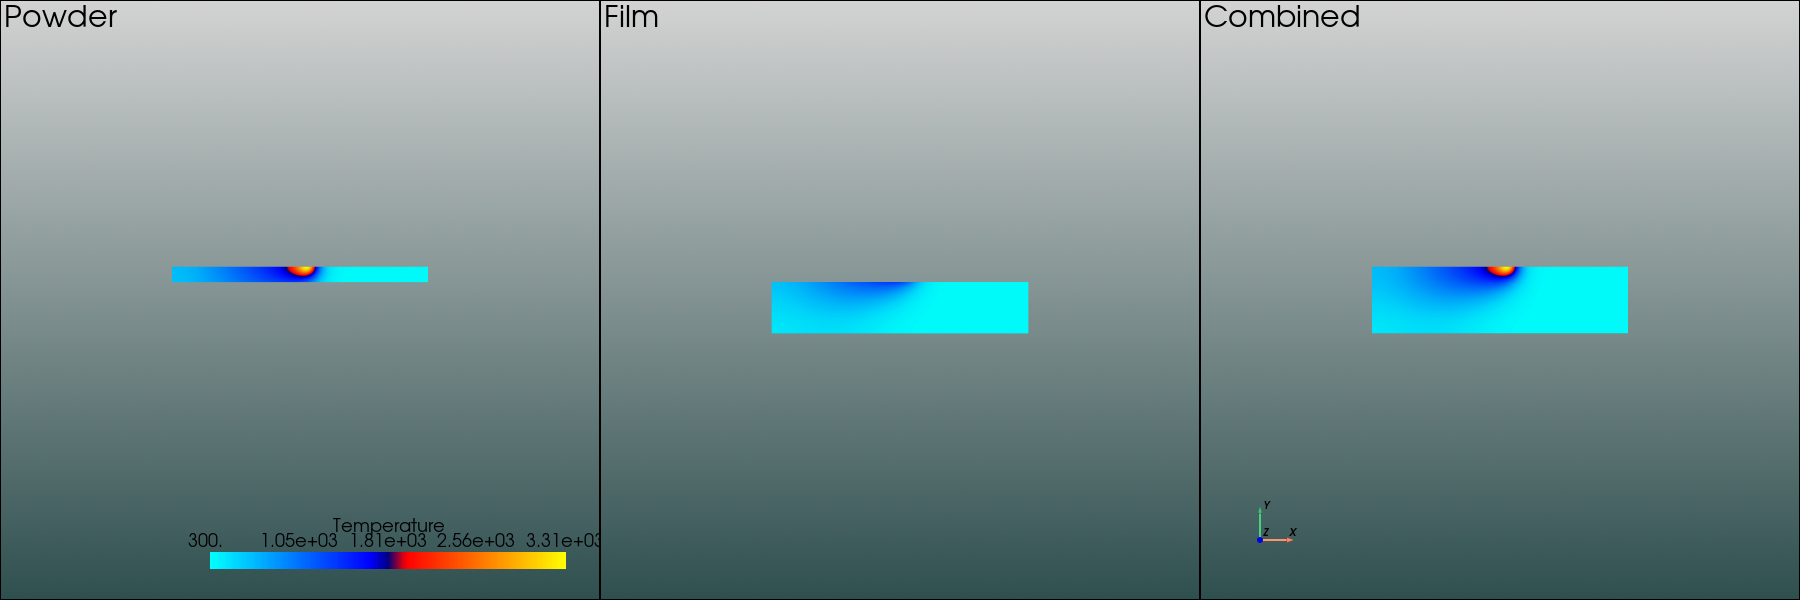

In [62]:
timestep = 500
variable_t = variable_data[timestep, :]

# Assign nodal temperature to meshes
grid_powder["Temperature"] = variable_t
grid_film["Temperature"]   = variable_t

cmap = cold2hot #'rainbow'

# --- Plot side-by-side ---
plotter = pv.Plotter(shape=(1,3))

plotter.subplot(0,0)
plotter.add_mesh(grid_powder, scalars="Temperature", cmap=cmap)
plotter.add_text("Powder", font_size=12)
plotter.view_vector([0.0, 0.0, 1.0], viewup=[0,0,0]) 

plotter.subplot(0,1)
plotter.add_mesh(grid_film, scalars="Temperature", cmap=cmap)
plotter.add_text("Film", font_size=12)
plotter.view_vector([0.0, 0.0, 1.0], viewup=[0,0,0]) 


plotter.subplot(0,2)
plotter.add_mesh(grid_powder, scalars="Temperature", cmap=cmap)
plotter.subplot(0,2)
plotter.add_mesh(grid_film, scalars="Temperature", cmap=cmap)
plotter.add_text("Combined", font_size=12)
plotter.view_vector([0.0, 0.0, 1.0], viewup=[0,0,0]) 


plotter.set_background("darkslategray", top="lightgray")
plotter.enable_3_lights()
plotter.show_axes()


plotter.show(window_size=(1800,600), jupyter_backend='static')

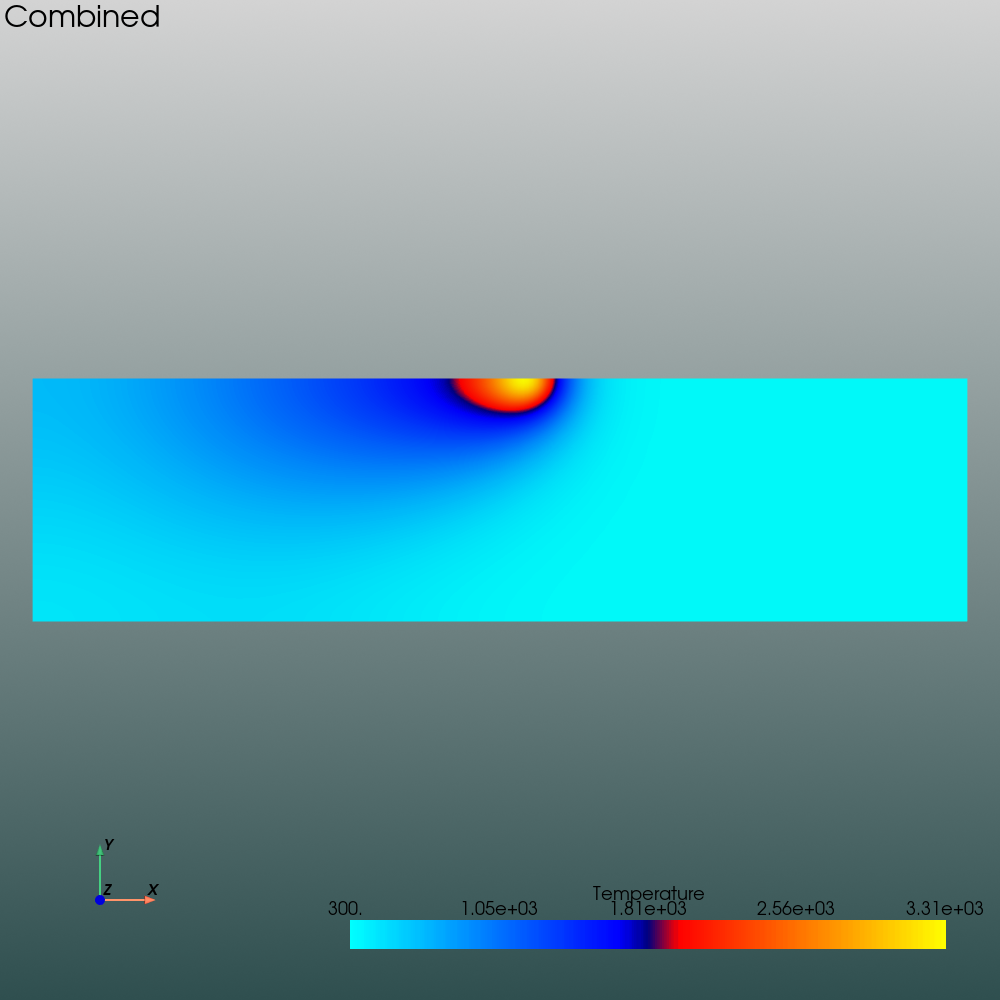

In [58]:
timestep = 500
variable_t = variable_data[timestep, :]

# Assign nodal temperature to meshes
grid_powder["Temperature"] = variable_t
grid_film["Temperature"]   = variable_t

cmap = cold2hot #'rainbow'

# --- Plot side-by-side ---
plotter = pv.Plotter(shape=(1,1), )


plotter.subplot(0,0)
plotter.add_mesh(grid_powder, scalars="Temperature", cmap=cmap)
plotter.subplot(0,0)
plotter.add_mesh(grid_film, scalars="Temperature", cmap=cmap)
plotter.add_text("Combined", font_size=12)
plotter.view_vector([0.0, 0.0, 1.0], viewup=[0,0,0]) 


plotter.set_background("darkslategray", top="lightgray")
plotter.enable_3_lights()
plotter.show_axes()


plotter.show(window_size=(1000,1000), jupyter_backend='static')